# Nucleus Detection And Classification

Click to open in: \[[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/12-nucleus-detection.ipynb)\]\[[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/12-nucleus-detection.ipynb)\]



## About this notebook

This jupyter notebook can be run on any computer with a standard browser and no prior installation of any programming language is required. It can run remotely over the Internet, free of charge, thanks to Google Colaboratory. To connect with Colab, click on one of the two blue checkboxes above. Check that "colab" appears in the address bar. You can right-click on "Open in Colab" and select "Open in new tab" if the left click does not work for you. Familiarize yourself with the drop-down menus near the top of the window. You can edit the notebook during the session, for example substituting your own image files for the image files used in this demo. Experiment by changing the parameters of functions. It is not possible for an ordinary user to permanently change this version of the notebook on GitHub or Colab, so you cannot inadvertently mess it up. Use the notebook's File Menu if you wish to save your own (changed) notebook.

To run the notebook on any platform, except for Colab, set up your Python environment, as explained in the
[README](https://tia-toolbox.readthedocs.io/en/latest/installation.html) file.



## About this demo

### Why is nucleus detection important?

Each whole slide image (WSI) can contain up to millions of nuclei of various types, which can be further quantified systematically and used for predicting clinical outcomes. In order to perform nuclei quantification for downstream analysis within computational pathology, nucleus detection and classification must be carried out as an initial step. However, this is challenging because nuclei display a high level of heterogeneity and there is significant inter- and intra-instance variability in the shape, size and chromatin pattern between and within different cell types, disease types or even from one region to another within a single tissue sample.

> ![image](https://github.com/Jiaqi-Lv/KongNet_Inference_Main/raw/main/docs/example_zoomed_in.png)

### What you'll learn in this notebook

In this tutorial, we will demonstrate how you can use the TIAToolbox implementation of [KongNet](https://arxiv.org/abs/2510.23559) to tackle these challenges and solve the problem of nuclei detection and classification within histology images. KongNet is a multi-headed deep learning architecture featuring a shared encoder and parallel, cell-type-specialized decoders. We validated KongNet in three Grand Challenges. It achieved first place on track 1 and second place on track 2 during the [MONKEY Challenge](https://monkey.grand-challenge.org/). Its lightweight variant (KongNet-Det) secured first place in the 2025 [MIDOG Challenge](https://midog2025.grand-challenge.org/). KongNet ranked among the top three in the [PUMA Challenge](https://puma.grand-challenge.org/) without further optimization. Furthermore, KongNet established state-of-the-art performance on the publicly available [PanNuke](https://arxiv.org/abs/2003.10778) and [CoNIC](https://arxiv.org/abs/2111.14485) datasets.

### What this notebook covers

In this example notebook, we won't explain how KongNet works internally (for more information we refer you to the [KongNet paper](https://arxiv.org/abs/2510.23559)). Instead, we will focus on the practical aspects:

1. **Patch-based detection**: How to run nucleus detection on individual image patches
1. **WSI-based detection**: How to process entire whole slide images efficiently
1. **Multiple detection tasks**: Examples including mitosis detection and lymphocyte/monocyte detection
1. **Results interpretation**: Understanding and visualizing the output
1. **Interactive visualization**: Using TIAViz to explore results on WSIs

We'll be working primarily with the [NucleusDetector](https://tia-toolbox.readthedocs.io/en/latest/_autosummary/tiatoolbox.models.engine.nucleus_detector.NucleusDetector.html) class which uses pretrained [KongNet](https://tia-toolbox.readthedocs.io/en/latest/_autosummary/tiatoolbox.models.architecture.kongnet.KongNet.html) models. We will also cover the [visualization interface](https://tia-toolbox.readthedocs.io/en/latest/visualization.html) embedded in TIAToolbox for overlaying the nuclei detection results on whole slide images.



## Setting up the environment

### TIAToolbox and dependencies installation

You can skip the following cell if 1) you are not using the Colab plaform or 2) you are using Colab and this is not your first run of the notebook in the current runtime session. If you nevertheless run the cell, you may get an error message, but no harm will be done. On Colab the cell installs `tiatoolbox`, and other prerequisite software. Harmless error messages should be ignored. Outside Colab , the notebook expects `tiatoolbox` to already be installed. (See the instructions in [README](https://tia-toolbox.readthedocs.io/en/latest/installation.html).)



In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools libpixman-1-dev | tail -n 1
pip install uv
uv pip install tiatoolbox | tail -n 1
echo "Installation is done."

> **IMPORTANT**: If you are using Colab and you run the cell above for the first time, please note that you need to restart the session before proceeding through (menu) *"Runtime→Restart session"* . This is needed to load the latest versions of prerequisite packages installed with TIAToolbox. Doing so, you should be able to run all the remaining cells altogether (*"Runtime→Run after"* from the next cell) or one by one.



### Importing related libraries

We import several essential libraries for this tutorial:

- **Standard libraries**: `pathlib`, `logging`, `warnings` for basic functionality
- **Visualization**: `matplotlib` for plotting results
- **Deep learning**: `torch` (PyTorch) for running the neural network models
- **Data handling**: `huggingface_hub` for downloading sample data
- **TIAToolbox modules**:
  - `NucleusDetector`: The main class for running nucleus detection
  - `WSIReader`: For reading and processing whole slide images (see [details](https://github.com/TIA-Lab/tiatoolbox/blob/master/tiatoolbox/wsicore/wsireader.py))
  - `SQLiteStore`: For storing and retrieving annotation data
  - `imread`: Utility function for reading images



In [ ]:
"""Import modules required to run the Jupyter notebook."""

# Standard library imports
import gc
import logging
import sys
import warnings
from pathlib import Path

# Third-party imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from huggingface_hub import hf_hub_download

# TIAToolbox imports
from tiatoolbox import logger
from tiatoolbox.annotation.storage import SQLiteStore
from tiatoolbox.models.engine.nucleus_detector import NucleusDetector
from tiatoolbox.utils.misc import imread
from tiatoolbox.wsicore.wsireader import WSIReader

# Add parent directory to path for importing from parent directory
sys.path.append("..")

# Clear logger to use tiatoolbox.logger
if logging.getLogger().hasHandlers():
    logging.getLogger().handlers.clear()

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

if "google.colab" in sys.modules:
    from google.colab import output

    output.enable_custom_widget_manager()
    logger.info("Custom widget manager enabled in Google Colab environment.")

# Configure matplotlib for high-quality notebook output
mpl.rcParams["figure.dpi"] = 300  # High resolution figures
mpl.rcParams["figure.facecolor"] = "white"  # Ensure visibility in dark mode
plt.rcParams.update({"font.size": 5})

### GPU or CPU runtime

Processes in this notebook can be accelerated by using a GPU. Therefore, whether you are running this notebook on your system or Colab, you need to check and specify appropriate [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) e.g., "cuda" or "cpu" whether you are using GPU or CPU. In Colab, you need to make sure that the runtime type is set to GPU in the *"Runtime→Change runtime type→Hardware accelerator"*. If you are *not* using GPU, consider changing the `device` flag to `cpu` value, otherwise, some errors will be raised when running the following cells.



In [2]:
# Automatically detect the best available device (GPU if available, else CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
logger.info("Using device: %s", device)

### Removing leftovers from previous runs

The cell below removes some redundant directories if they exist—a previous run may have created them. This cell can be skipped if you are running this notebook for the first time.



In [3]:
%%bash
rm -rf ./tmp/patch_results/
echo "deleting patch_results directory"

rm -rf ./tmp/wsi_results/
echo "deleting wsi_results directory"

deleting patch_results directory
deleting wsi_results directory


### Downloading the required files

We download sample images from the TIAToolbox repository hosted on Hugging Face. This includes:

1. **CMC_patch_image_path**: A single image patch from a mitosis detection dataset (MIDOG 2025) - used to demonstrate detection on small images.
1. **CMC_wsi_path**: A whole slide image (.svs format) from the same dataset - used to demonstrate WSI processing.
1. **PAS_wsi_path**: A PAS-stained kidney biopsy slide (.tif format) - used to demonstrate lymphocyte and monocyte detection.
1. **PAS_wsi_mask_path**: A region-of-interest binary mask for the PAS WSI above - used in this notebook for the purpose of limiting the prediction area which saves time and memory.

These samples allow us to demonstrate different use cases: mitosis detection in breast tissue and immune cell detection in kidney tissue.

> **Tip for Colab users**: If you click the files icon (see below) in the vertical toolbar on the left hand side, you can see all the files that the code in this notebook can access. The downloaded data will appear in the `tmp/` folder when the download completes.
>
> 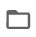



In [3]:
# Define the temporary directory for storing downloaded files and results
tmp_dir = Path("./tmp/")
tmp_dir.mkdir(exist_ok=True, parents=True)

# Repository information for downloading sample data
REPO_ID = "TIACentre/TIAToolBox_Remote_Samples"
REPO_TYPE = "dataset"

logger.info("Download has started. Please wait...")

# Download sample patch image for mitosis detection
CMC_patch_image_path = hf_hub_download(
    repo_id=REPO_ID,
    subfolder="sample_imgs",
    filename="MIDOG_CMC_2191a7aa287ce1d5dbc0.png",
    repo_type=REPO_TYPE,
    local_dir=tmp_dir,
)
logger.info("Downloaded patch image: %s", CMC_patch_image_path)

# Download WSI for mitosis detection (breast tissue, H&E stain)
CMC_wsi_path = hf_hub_download(
    repo_id=REPO_ID,
    subfolder="sample_wsis",
    filename="MIDOG_CMC_2191a7aa287ce1d5dbc0.svs",
    repo_type=REPO_TYPE,
    local_dir=tmp_dir,
)
logger.info("Downloaded CMC WSI: %s", CMC_wsi_path)

# Download WSI for lymphocyte/monocyte detection (kidney tissue, PAS stain)
PAS_wsi_path = hf_hub_download(
    repo_id=REPO_ID,
    subfolder="sample_wsis",
    filename="D_P000019_PAS_CPG.tif",
    repo_type=REPO_TYPE,
    local_dir=tmp_dir,
)
logger.info("Downloaded PAS WSI: %s", PAS_wsi_path)

PAS_wsi_mask_path = hf_hub_download(
    repo_id=REPO_ID,
    subfolder="sample_wsis",
    filename="D_P000019_PAS_CPG_roi_mask.png",
    repo_type=REPO_TYPE,
    local_dir=tmp_dir,
)

logger.info("Download is complete.")

## Mitosis Detection using TIAToolbox's pretrained KongNet model

In this section, we will demonstrate the use of the pretrained KongNet models for Mitosis Detection. The model we demonstrate can detect mitotic figures in the image and output their coordinates.



#### Setting up the detector

First, we create an instance of the `NucleusDetector` class, which controls the entire nucleus detection pipeline. Then we call its `run()` method to perform detection on our input image(s).



In [4]:
# Initialize the nucleus detector with the mitosis detection model
detector = NucleusDetector(
    model="KongNet_Det_MIDOG_1",  # Pretrained model for mitosis detection
    batch_size=1,
    num_workers=0,
    weights=None,  # Use default pretrained weights
    device=device,
    verbose=True,
)

# Run detection on the patch image
logger.info("Running nucleus detection on patch image...")
patch_output = detector.run(
    images=[CMC_patch_image_path],
    patch_mode=True,  # Treat input as a patch, not a WSI
    device=device,
    save_dir=tmp_dir / "patch_results",
    overwrite=True,
    output_type="annotationstore",  # Store results as annotation database
    auto_get_mask=False,  # Not needed for small patches
    memory_threshold=50,
    num_workers=4,
    batch_size=8,
    class_dict={0: "mitotic_figure"},  # Map class index to class name
)

logger.info("Patch detection complete. Results saved to: %s", patch_output[0])

GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.


Inferring patches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing detection blocks:   0%|          | 0/1 [00:00<?, ?it/s]

Writing detections to store:   0%|          | 0/1 [00:00<?, ?it/s]

#### Understanding the parameters

With just a few lines of code, you can process thousands of images automatically! Let's understand the key parameters:

##### NucleusDetector initialization parameters:

- `model`: Specifies the name of the pretrained model included in TIAToolbox (case sensitive). You can find a complete list of currently available pretrained models [here](https://tia-toolbox.readthedocs.io/en/latest/pretrained.html). In this example, we use the `"KongNet_Det_MIDOG_1"` pretrained model, which is the KongNet-Det model trained on the [MIDOG2025 dataset](https://zenodo.org/records/15077361) for mitosis detection. There are also many other pretrained KongNet models, such as `"KongNet_CoNIC_1"` for nuclear segmentation and classification.

- `batch_size`: Controls the batch size, or the number of input instances to the network in each iteration. If you use a GPU, be careful not to set the `batch_size` larger than the GPU memory limit would allow.

- `num_workers`: Controls the number of CPU cores (workers) responsible for the inference process, which consists of patch extraction, preprocessing, postprocessing, etc.

- `weights`: Optional path to pretrained weights. If `None` and `model` is a string, default pretrained weights for that model will be used. If `model` is an `nn.Module`, weights are loaded only if provided.

- `device`: Device on which the model will run (e.g., `"cpu"`, `"cuda"`). Default is `"cpu"`.

- `verbose`: Whether to output logging information. Default is `True`.

##### NucleusDetector.run() parameters:

After the `detector` has been instantiated with our desired pretrained model, we call the `run()` method to perform inference on a list of input image patches (or WSIs). The `run()` function automatically:

1. Processes all images in the input list
1. Extracts patches (if `patch_mode=False` and input is a WSI)
1. Runs preprocessing, model inference, and postprocessing
1. Assembles predictions
1. Saves results to disk

Here are the important `run()` parameters:

- `images`: List of inputs to be processed. Can be a list of paths or numpy arrays.

- `patch_mode`: Whether to treat input as patches (`True`) or WSIs (`False`). Default is `True`.

- `device`: Specify appropriate [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) e.g., `"cuda"`, `"cuda:0"`, `"mps"`, `"cpu"`, etc.

- `save_dir`: Path to the main folder in which prediction results for each input will be stored, as well as any intermediate cache during WSI processing. We could set it to `None` when using `patch_mode=True`, in which case the results will simply be returned instead of saved to disk.

- `overwrite`: Whether to overwrite existing output files. Default is `False`.

- `output_type`: Desired output format: `"dict"`, `"zarr"`, or `"annotationstore"`. Default is `"dict"`. However, `"dict"` can only be used when `patch_mode` is `True`, otherwise we should use either `"zarr"` or `"annotationstore"`.

- `auto_get_mask`: Whether to automatically generate tissue masks using `wsireader.tissue_mask()` during processing. We don't normally need it for patch mode as patches are small in size and normally contain only tissue region.

- `memory_threshold`: Memory usage threshold (in percentage) to trigger caching behavior. Default is 80.

- `batch_size`: Controls the batch size (can override the initialization parameter here).

- `num_workers`: Controls the number of CPU workers (can override the initialization parameter here).

- `class_dict`: Optional dictionary mapping class indices to class names. This helps interpret the output by providing meaningful labels for detected nuclei (e.g., `{0: "mitotic_figure"}`).

#### Understanding the output

The `run()` function returns different outputs depending on the `output_type`:

- When `output_type="annotationstore"` (as used here), it returns a path (or list of paths) to SQLite database files containing the detection results
- Each annotation includes the nucleus location (coordinates), type/class, and geometric properties

Now let's examine the predictions and visualize them!



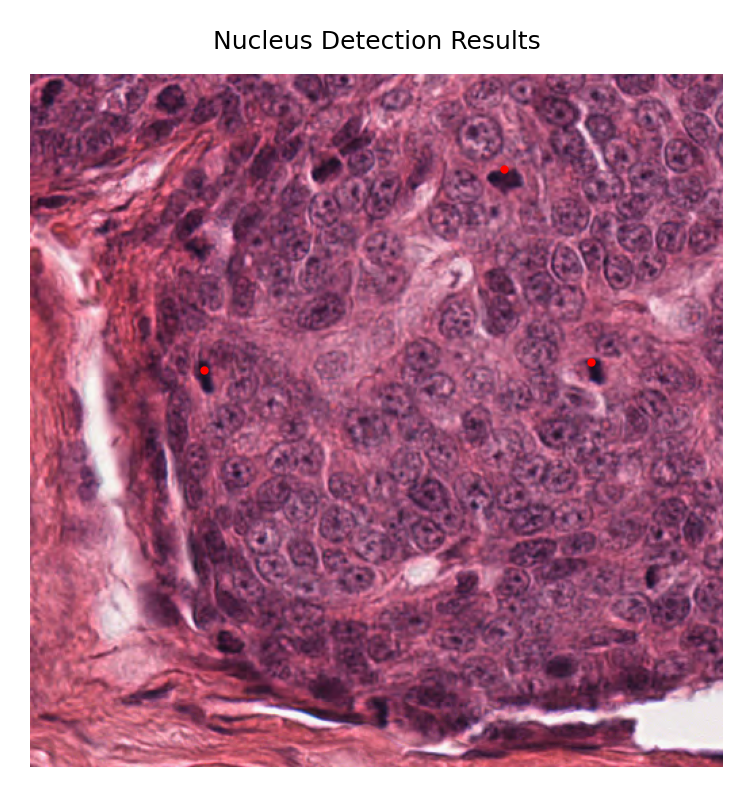

26262

In [5]:
patch_annotation_store_path = patch_output[0]

patch_annotation_store = SQLiteStore.open(patch_annotation_store_path)

x_coords = []
y_coords = []

for annotation in patch_annotation_store.values():
    x, y = annotation.geometry.centroid.coords[0]

    x_coords.append(x)
    y_coords.append(y)
    logger.info("%s, x: %.2f, y: %.2f", annotation.properties["type"], x, y)

patch_annotation_store.close()


patch_image = imread(CMC_patch_image_path)


fig, axes = plt.subplots(1, 1, figsize=(3, 3))
axes.imshow(patch_image)
axes.axis("off")

axes.scatter(y_coords, x_coords, s=1, c="red")
axes.set_title("Nucleus Detection Results")
axes.axis("off")
plt.show()

# Clean up variables to free up memory
del patch_image, x_coords, y_coords, detector, patch_annotation_store, patch_output
gc.collect()

### Inference on WSIs

#### Processing whole slide images

Now let's scale up to process an entire whole slide image! The process is similar to patch processing, but with some key differences:

1. **Automatic patch extraction**: The WSI is automatically divided into smaller patches for processing
1. **Tissue masking**: Optionally, we can automatically detect tissue regions to avoid processing empty background
1. **Result assembly**: All patch-level detections are assembled into a single output file
1. **Memory efficiency**: The system manages memory automatically, caching intermediate results if needed

#### Understanding tissue masking

The `auto_get_mask` parameter controls automatic tissue detection:

- When `True`: TIAToolbox automatically identifies tissue regions and only processes those areas (recommended for most WSIs)
- When `False`: The entire WSI is processed (useful when the image is mostly tissue or when you have custom masks)

Let's first look at the WSI we'll be processing:



Read: Scale > 1.This means that the desired resolution is higher than the WSI baseline (maximum encoded resolution). Interpolation of read regions may occur.


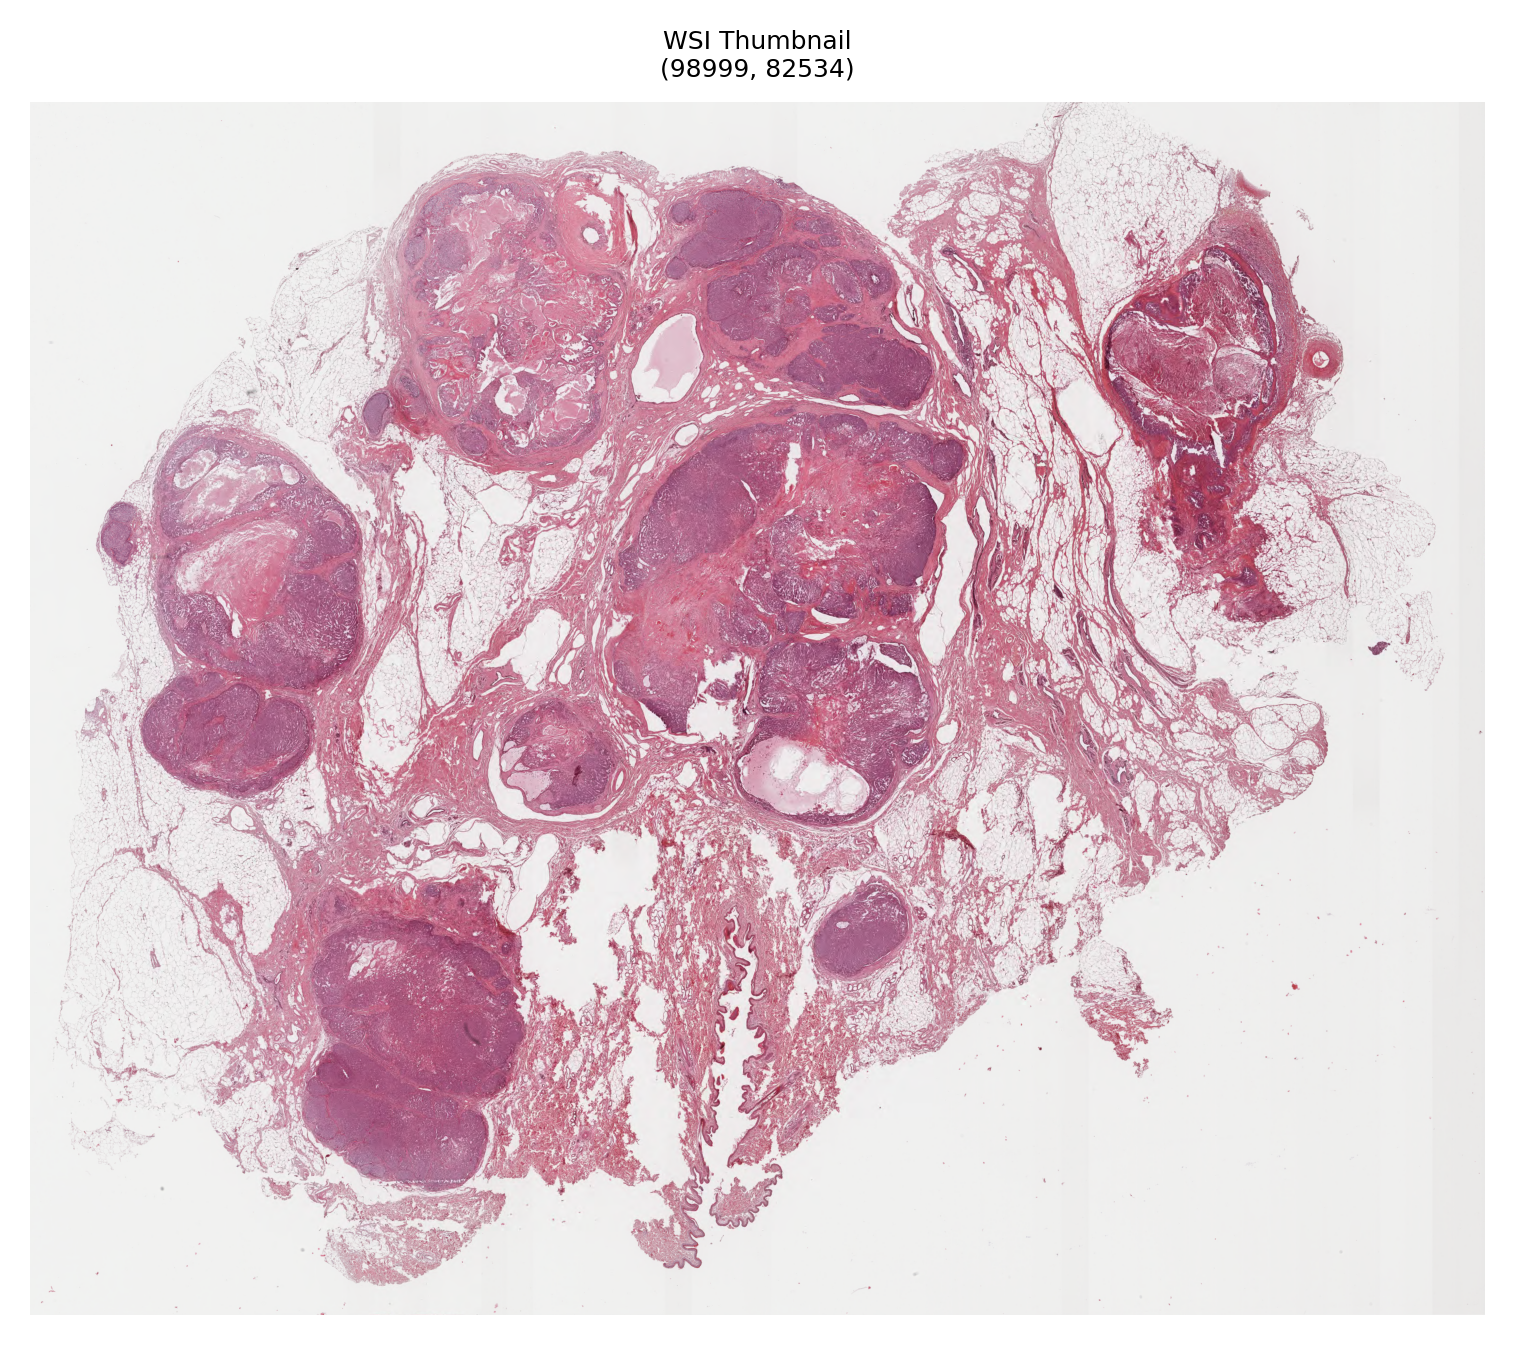

2414

In [6]:
# Open the WSI and display its metadata
wsi_reader = WSIReader.open(CMC_wsi_path)
wsi_info = wsi_reader.info.as_dict()

logger.info("WSI Information:")
logger.info("  Dimensions: %s", wsi_info.get("slide_dimensions"))
logger.info("  Vendor: %s", wsi_info.get("vendor"))
logger.info("  MPP: %s", wsi_info.get("mpp"))
logger.info("  Objective power: %s", wsi_info.get("objective_power"))

# Generate and display a thumbnail of the WSI
thumbnail = wsi_reader.slide_thumbnail()
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
axes.imshow(thumbnail)
axes.set_title(
    f"WSI Thumbnail\n{wsi_info.get('slide_dimensions', 'Unknown dimensions')}",
)
axes.axis("off")
plt.tight_layout()
plt.show()

del thumbnail
gc.collect()

In [ ]:
# Initialize detector for WSI processing
detector = NucleusDetector(
    model="KongNet_Det_MIDOG_1",
    device=device,
    verbose=True,
)

# Run detection on the whole slide image
logger.info("Starting WSI-level nucleus detection. This may take several minutes...")
wsi_output = detector.run(
    images=[Path(CMC_wsi_path)],
    masks=None,  # Will use automatic tissue masking
    patch_mode=False,  # Process as WSI, not as a single patch
    device=device,
    save_dir=tmp_dir / "wsi_results/",
    overwrite=True,
    output_type="annotationstore",
    auto_get_mask=True,  # Automatically detect and process only tissue regions
    memory_threshold=50,  # Memory threshold percentage for start caching
    num_workers=4,  # Use multiple workers for faster processing
    batch_size=8,  # Process 8 patches at a time
)

logger.info("WSI detection complete. Results: %s", wsi_output)

del detector
gc.collect()

#### Key differences from patch mode

Note the important parameter changes for WSI processing:

1. **`patch_mode=False`**: Tells TIAToolbox that the input is a whole slide image that needs to be divided into patches
1. **`auto_get_mask=True`**: Automatically generates a tissue mask to avoid processing background regions, saving time and reducing false detections
1. **`masks=None`**: We're not providing custom masks, so the automatic tissue detection will be used. You can provide custom masks as a list of paths if you have specific regions of interest
1. **`batch_size=8`**: Processing multiple patches in parallel (adjust based on your GPU memory)
1. **`memory_threshold=50`**: Threshold to trigger caching, useful for large WSIs

#### Processing time expectations

The cell above might take a while to process, especially if `device="cpu"`. Processing time depends on:

- WSI dimensions and resolution
- Amount of tissue present (with `auto_get_mask=True`, background is skipped)
- Hardware capabilities (GPU vs CPU, available RAM)
- Batch size and number of workers

#### Examining the results

The output is a dictionary mapping input WSI paths to their corresponding annotation store paths. Let's load and examine some of the detected nuclei:



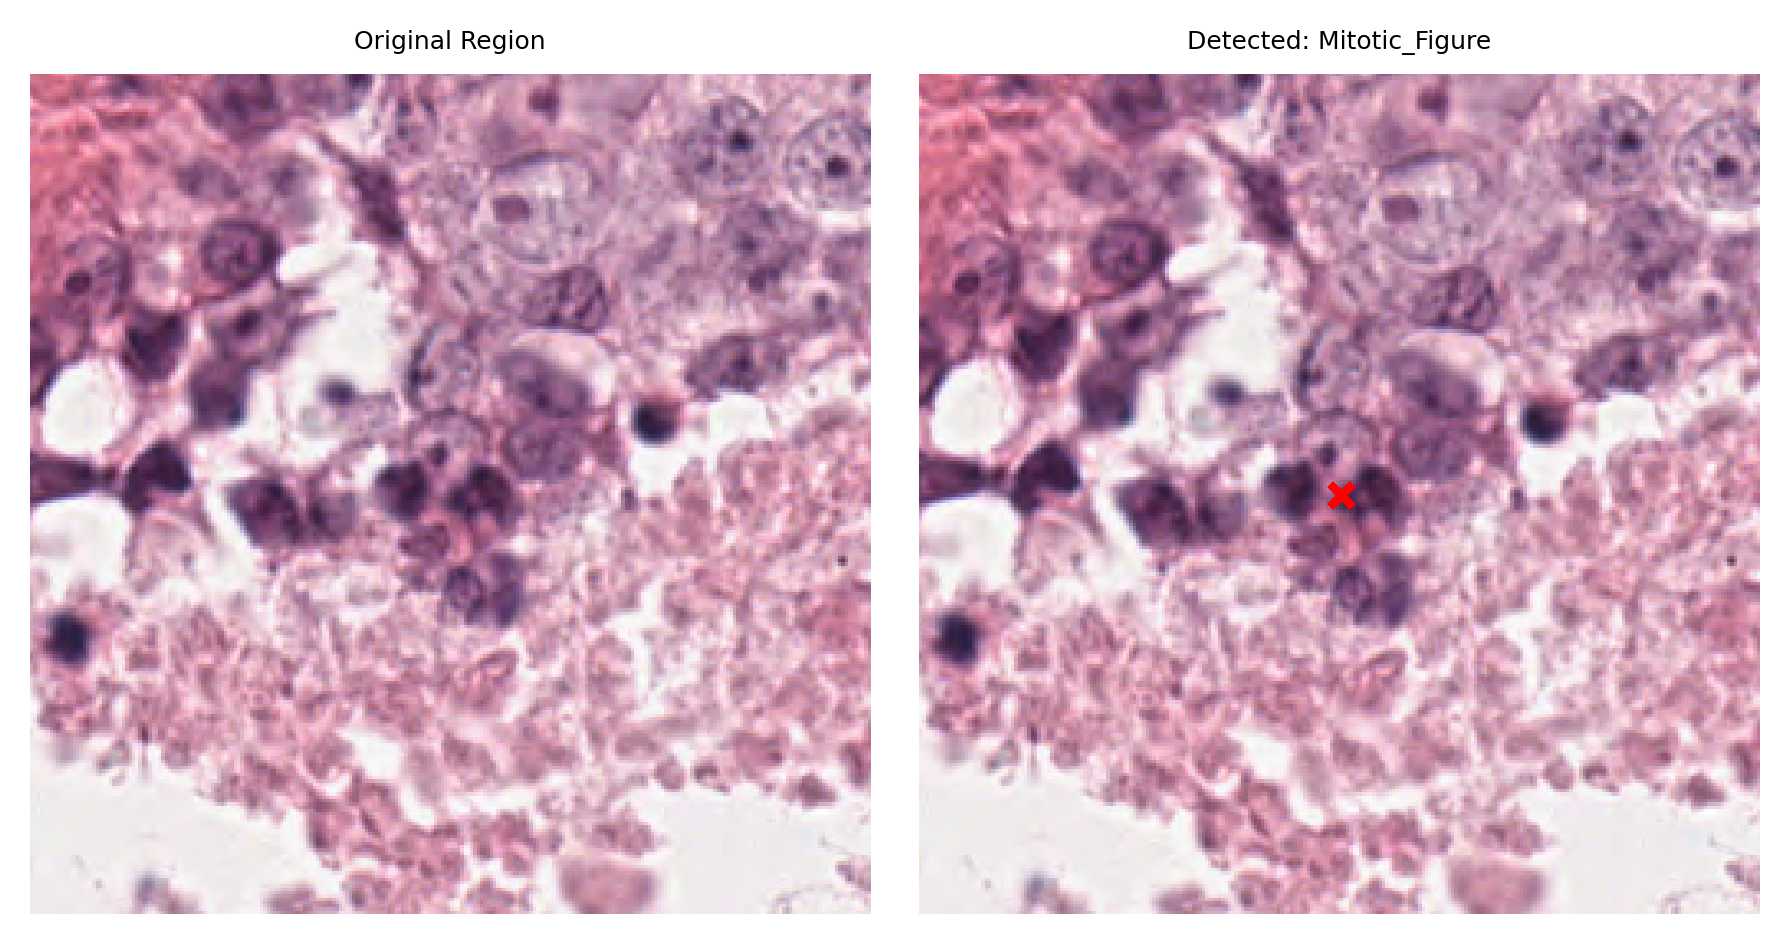

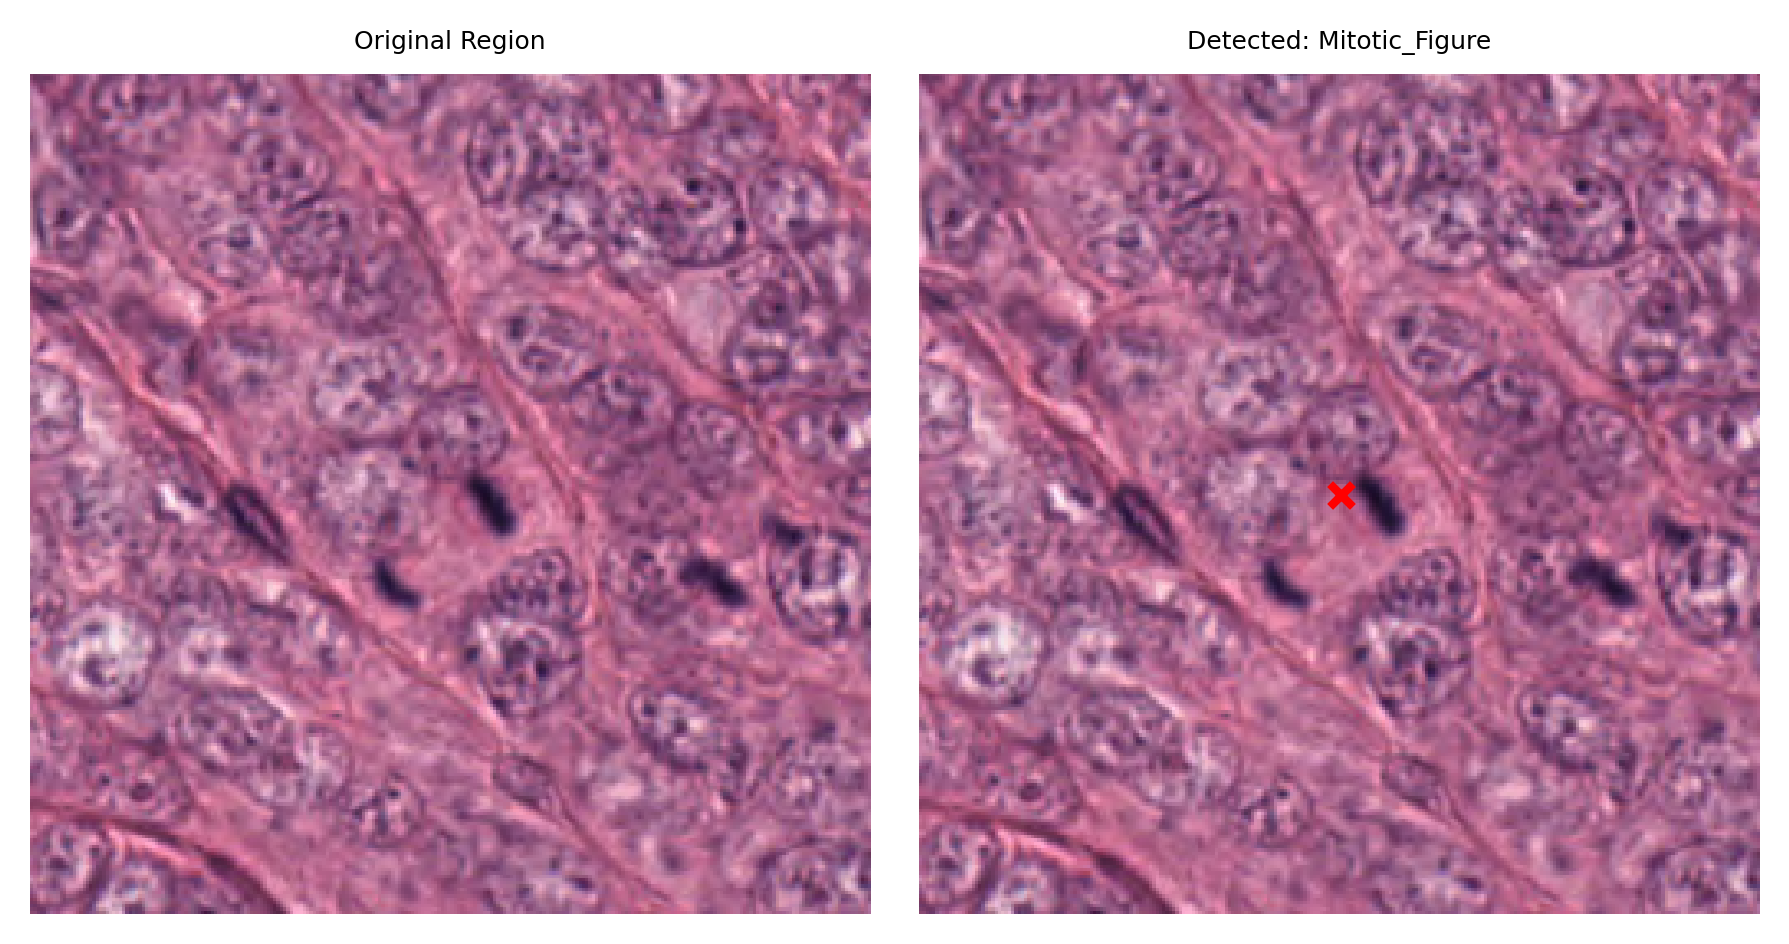

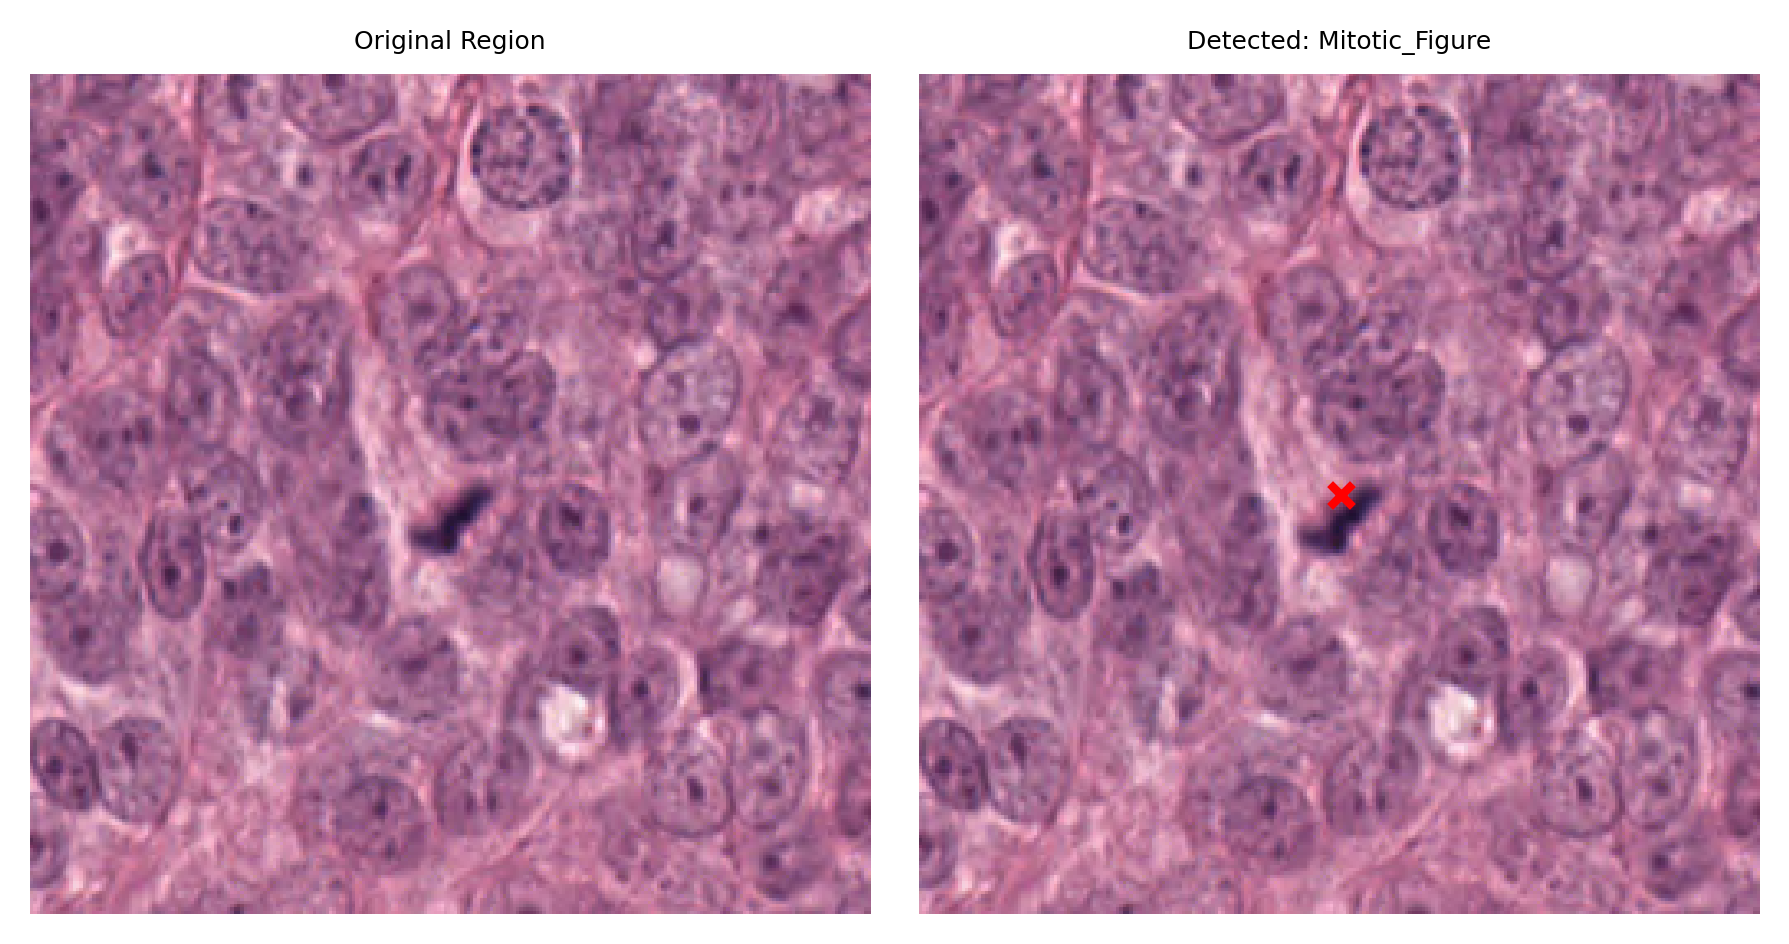

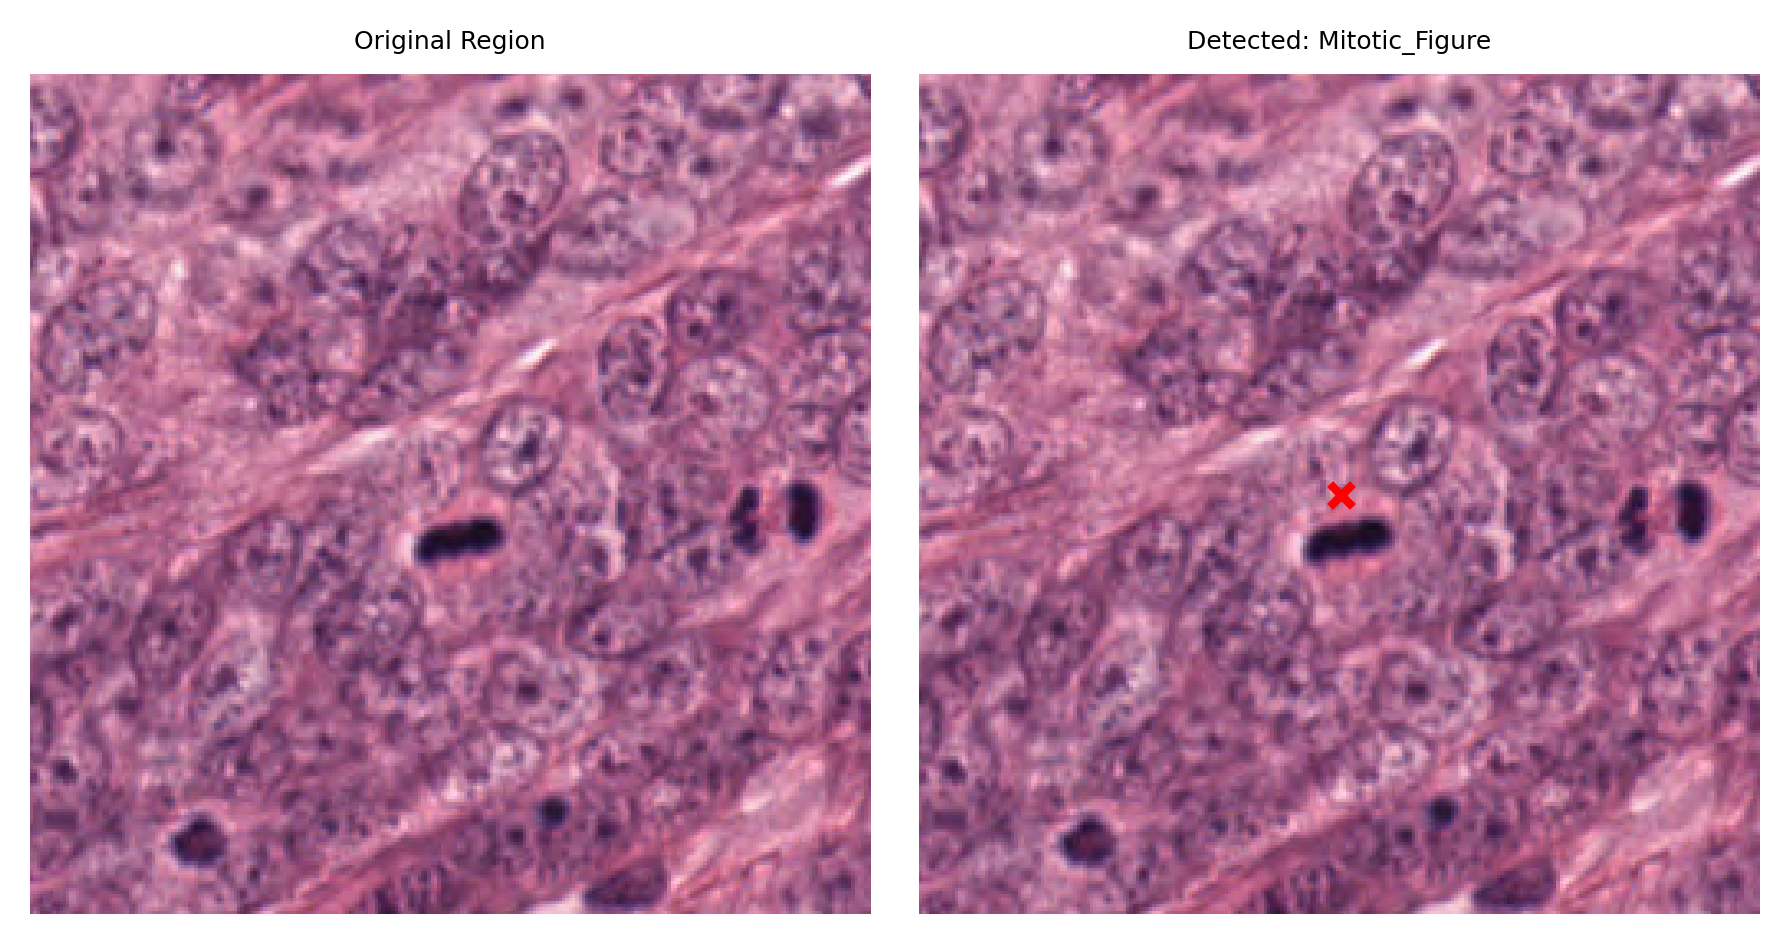

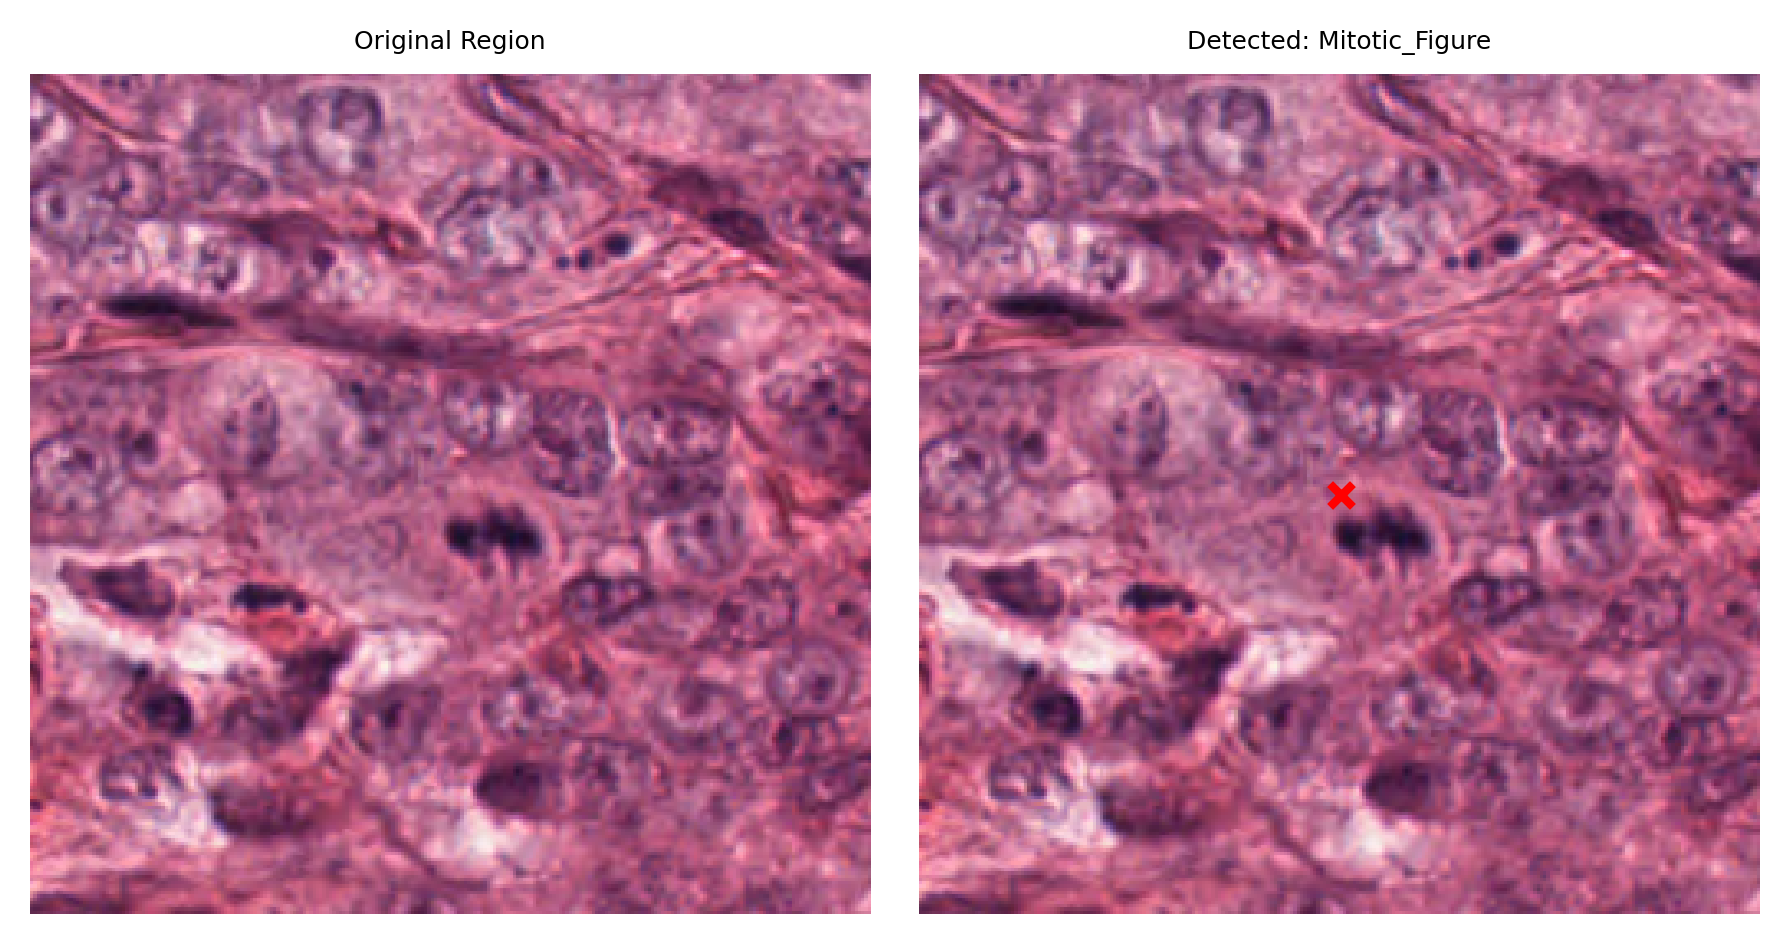

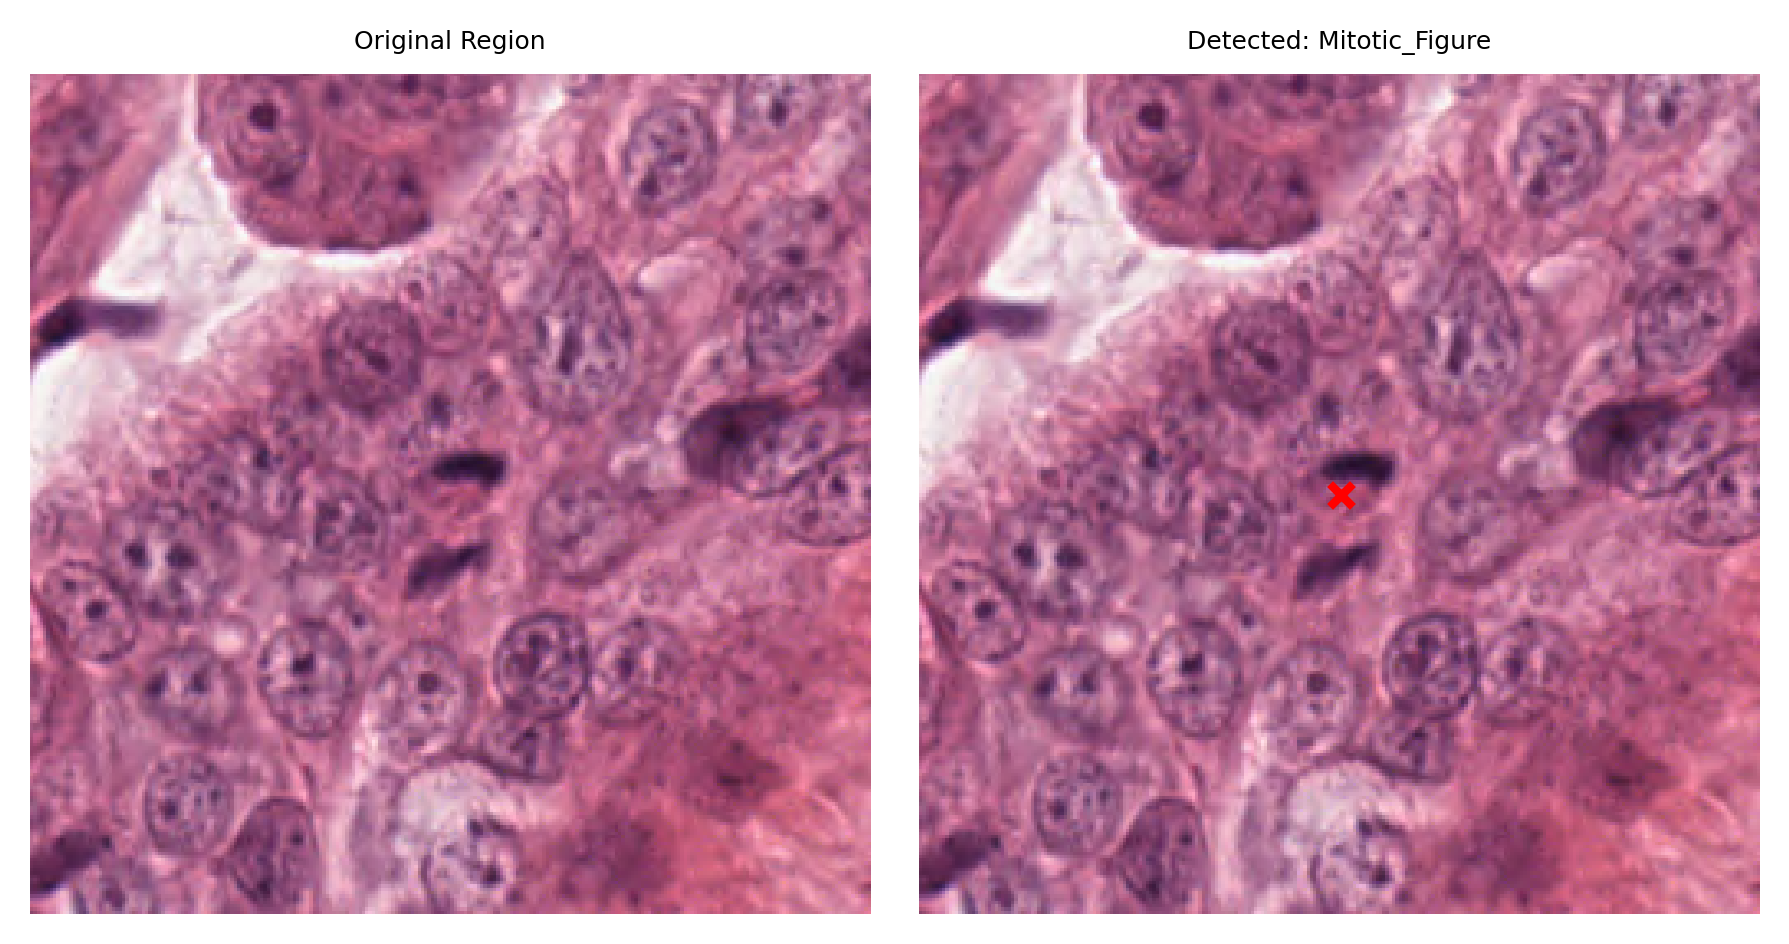

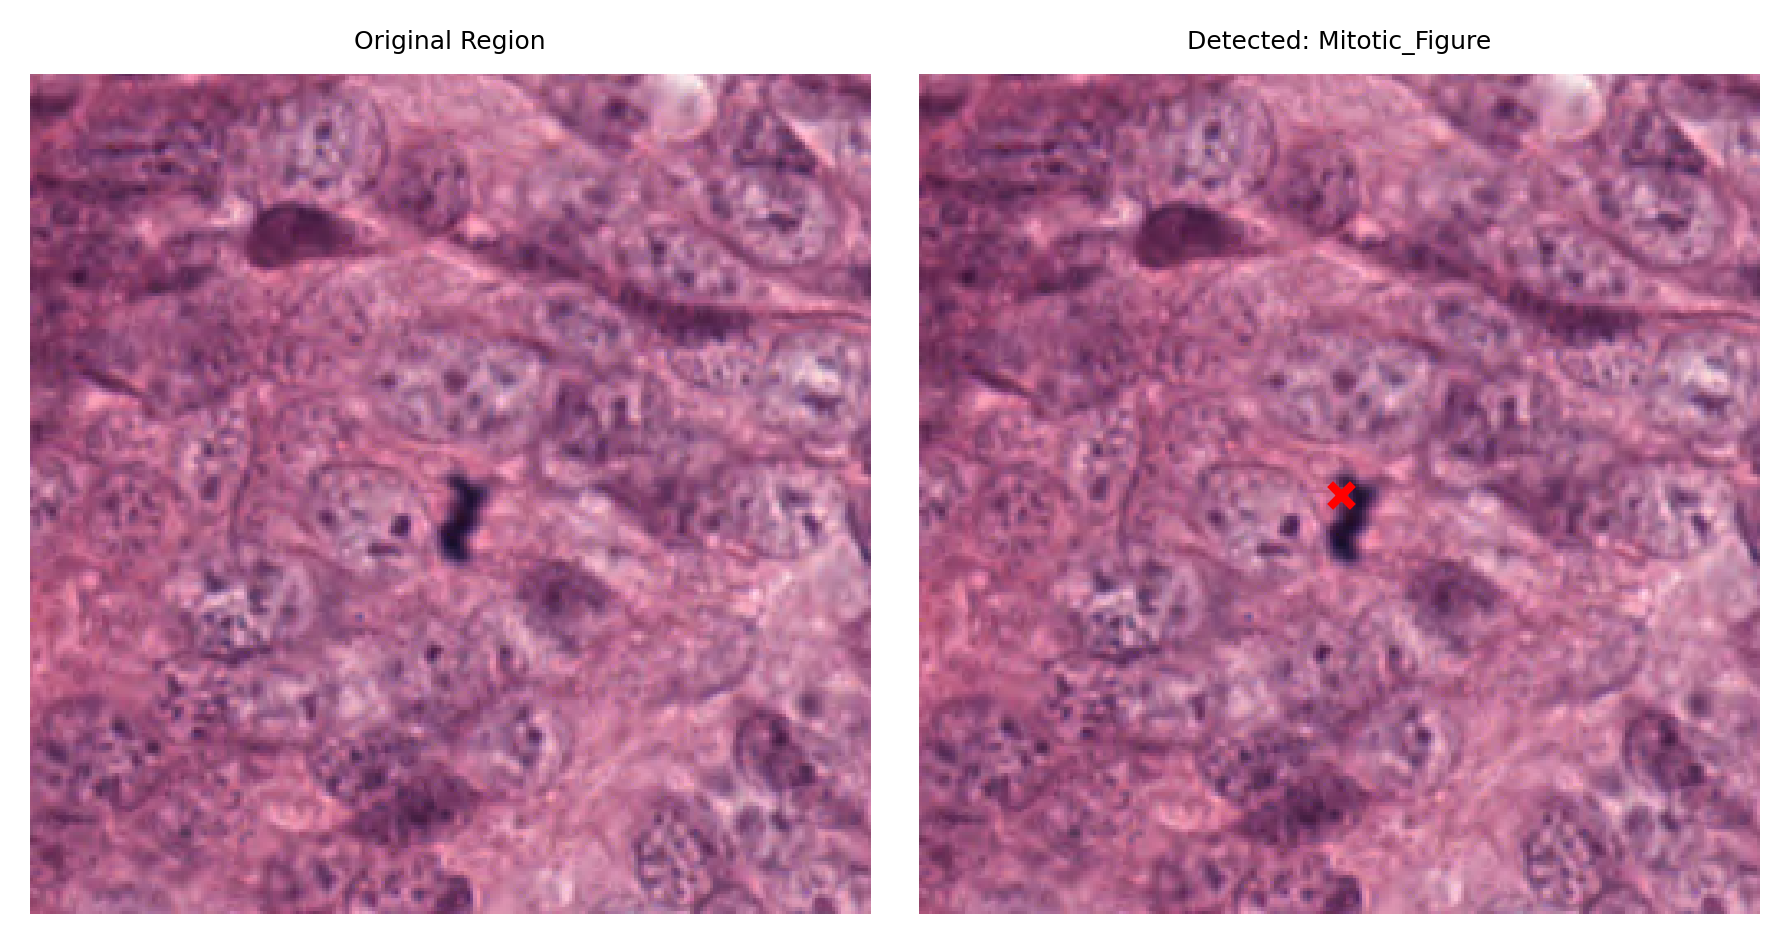

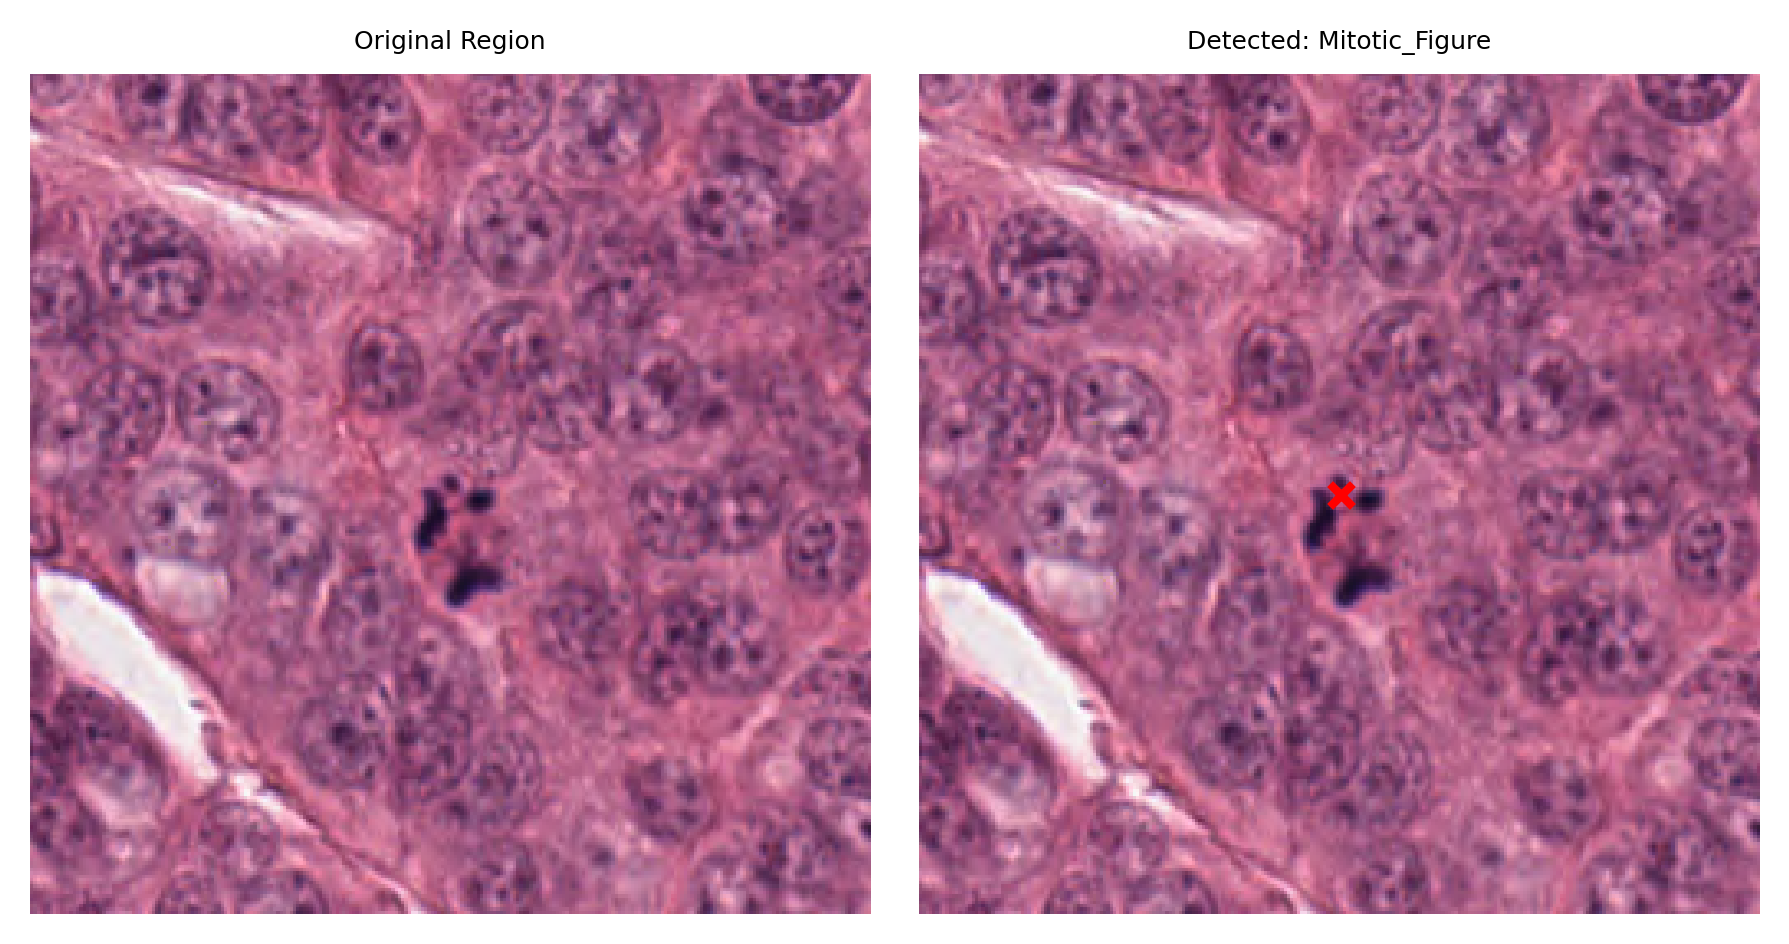

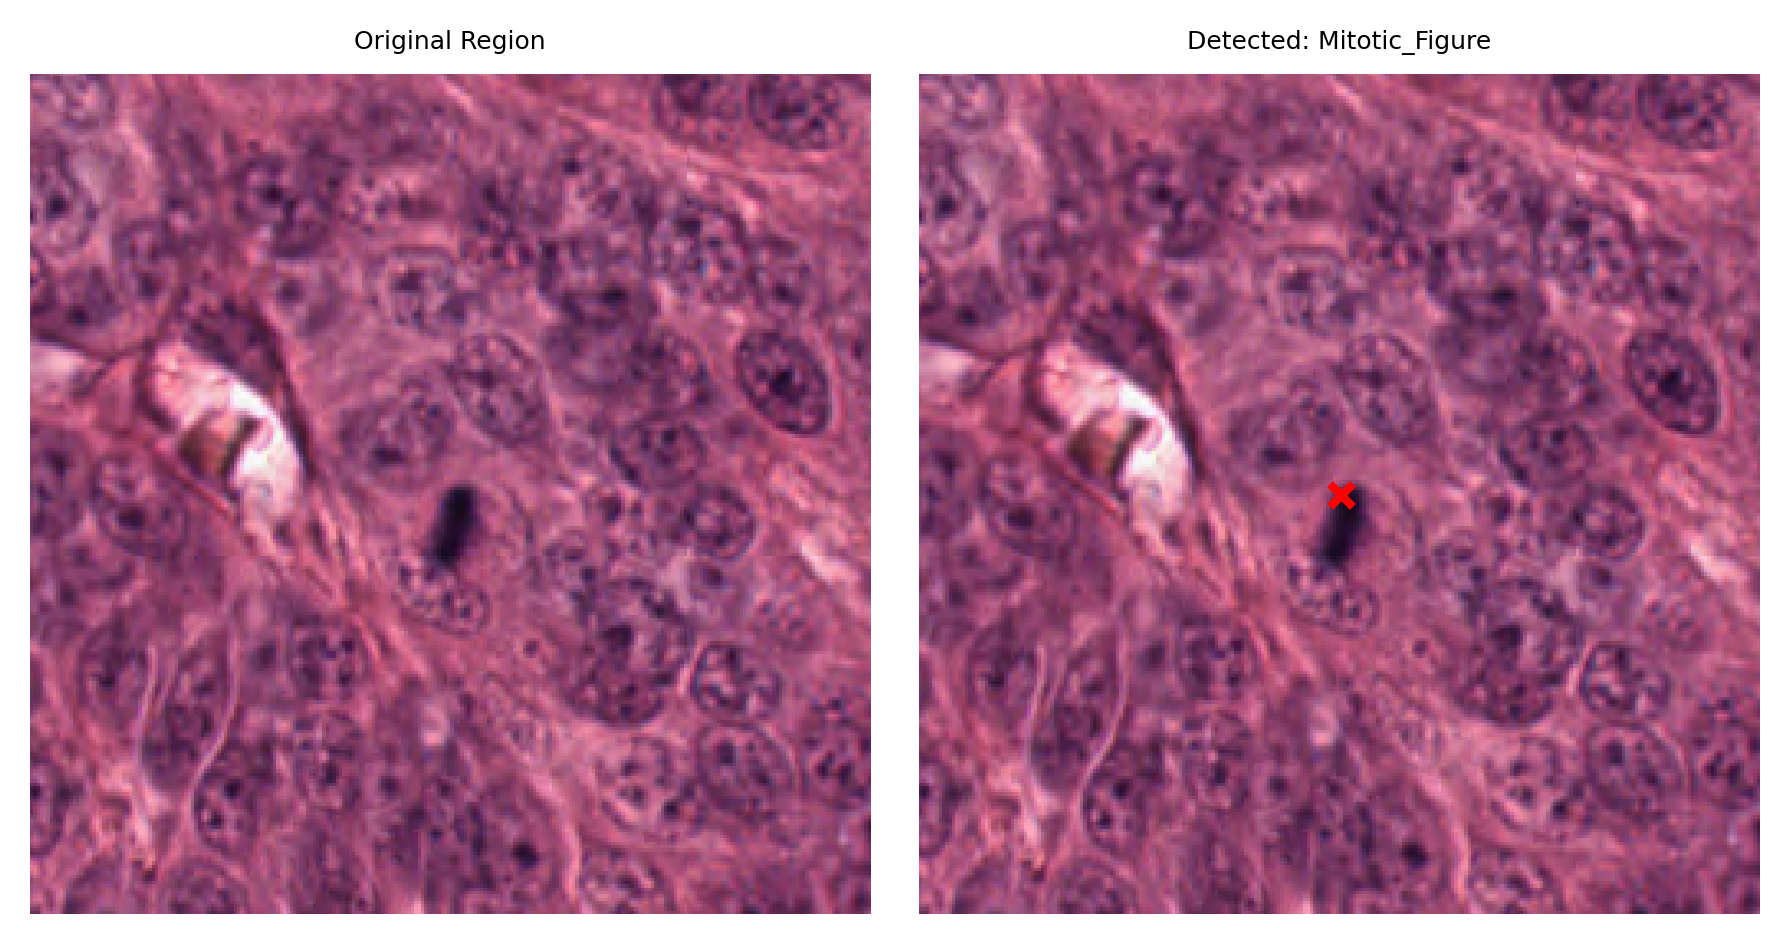

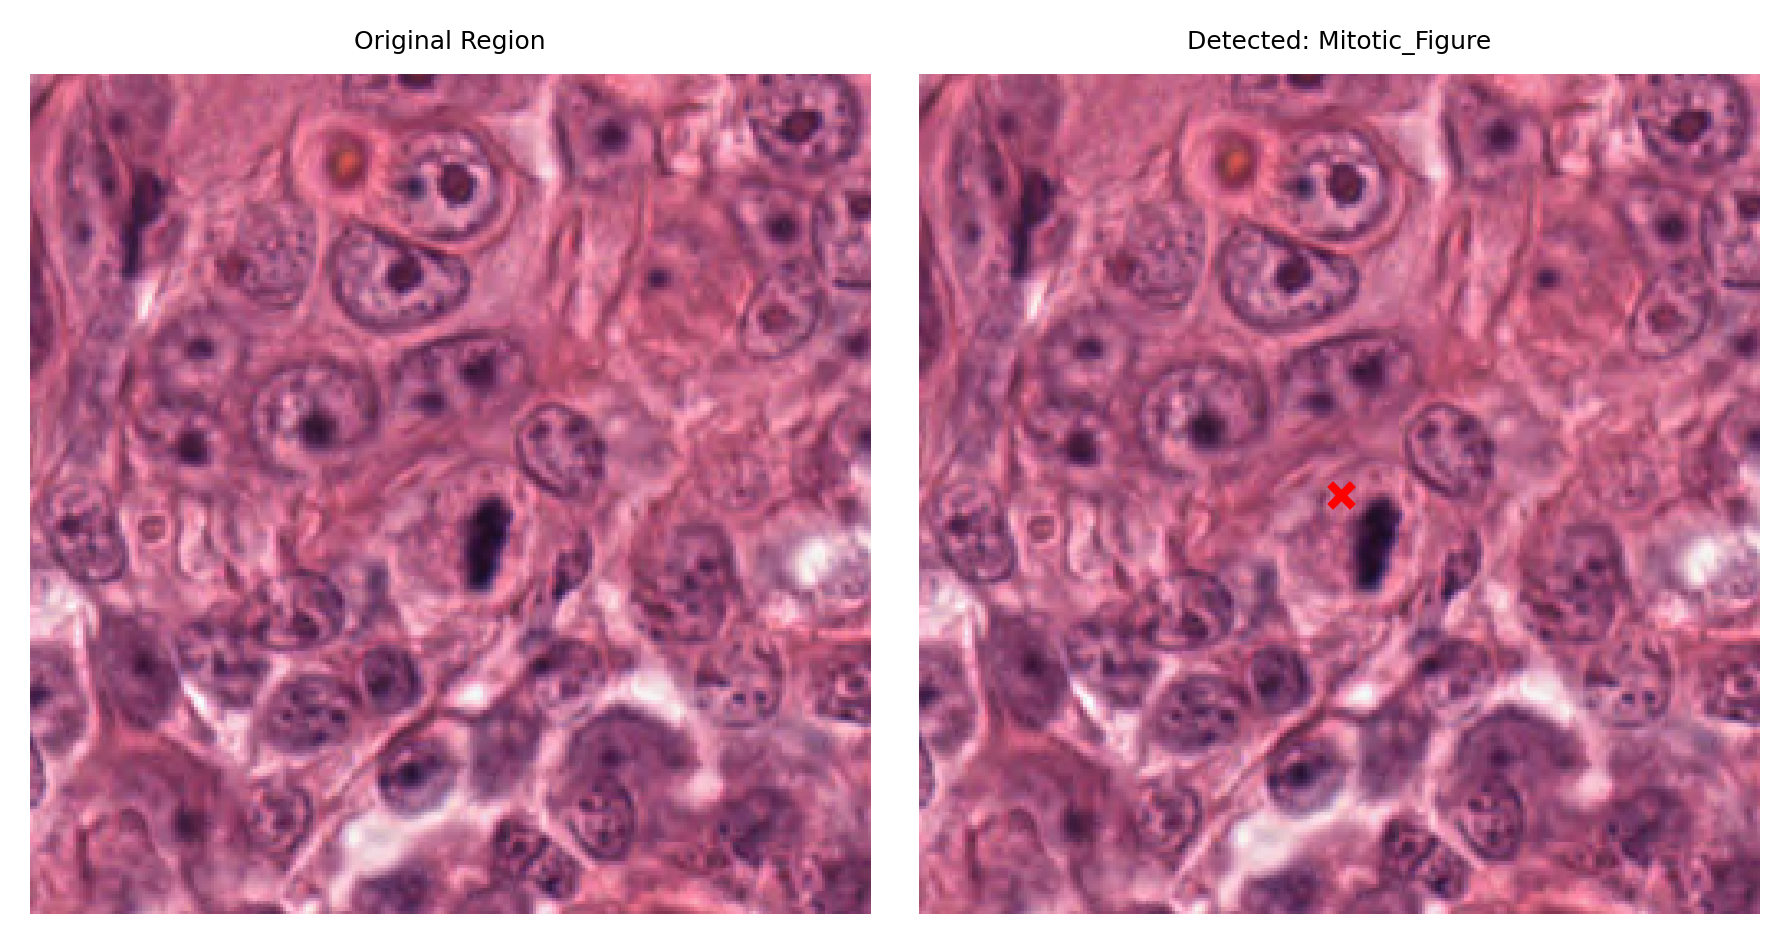

40175

In [8]:
# Load and explore the WSI detection results
logger.info("WSI output: %s", wsi_output)

wsi_annotation_store_path = wsi_output[Path(CMC_wsi_path)]
store = SQLiteStore.open(wsi_annotation_store_path)

total_detections = len(store)
logger.info("Total detections in WSI: %d", total_detections)

# Display a sample of detected nuclei with their surrounding context
max_annotations = min(10, total_detections)
logger.info("Displaying %d sample detections:", max_annotations)

# Parameters for extracting regions around detected nuclei
REGION_SIZE = 256  # Size of region to extract around each detection
HALF_REGION = REGION_SIZE // 2

for idx, ann in enumerate(list(store.values())[:max_annotations], start=1):
    # Get nucleus location
    x, y = ann.geometry.centroid.coords[0]
    nucleus_type = ann.properties.get("type", "unknown")

    logger.info(
        "Detection %d/%d: %s at (x: %.0f, y: %.0f)",
        idx,
        max_annotations,
        nucleus_type,
        x,
        y,
    )

    region = wsi_reader.read_rect(
        location=(int(x) - HALF_REGION, int(y) - HALF_REGION),
        size=(REGION_SIZE, REGION_SIZE),
        resolution=0,
        units="level",
    )

    # Visualize: original region and region with detection marked
    fig, ax = plt.subplots(figsize=(6, 3), nrows=1, ncols=2)

    # Left: original region
    ax[0].imshow(region)
    ax[0].set_title("Original Region")
    ax[0].axis("off")

    # Right: region with detection marked
    ax[1].imshow(region)
    ax[1].scatter(
        HALF_REGION,
        HALF_REGION,
        s=30,
        c="red",
        marker="x",
        linewidths=2,
    )
    ax[1].set_title(f"Detected: {nucleus_type}")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

store.close()

del store, region
gc.collect()

## Lymphocytes and Monocytes Detection in PAS-Stained WSI

### Different models for different tasks

One of the powerful features of TIAToolbox is the availability of multiple pretrained models for different detection tasks. Previously, we used `KongNet_Det_MIDOG_1` for mitosis detection in H&E-stained breast tissue. Now we'll use `KongNet_MONKEY_1`, which is trained on the [MONKEY Challenge dataset](https://zenodo.org/records/13794656) for detecting immune cells in PAS-stained kidney biopsies.

This model can detect:

- **Lymphocytes**
- **Monocytes**
- **Overall mononuclear leukocytes**

### Why different stains matter

Different tissue staining methods highlight different cellular components:

- **H&E (Hematoxylin and Eosin)**: Standard stain showing general tissue structure and nuclei
- **PAS (Periodic Acid-Schiff)**: Highlights carbohydrates and basement membranes, commonly used in kidney pathology

Using a model trained on the appropriate stain type improves detection accuracy.



Metadata: Objective power inferred from microns-per-pixel (MPP).


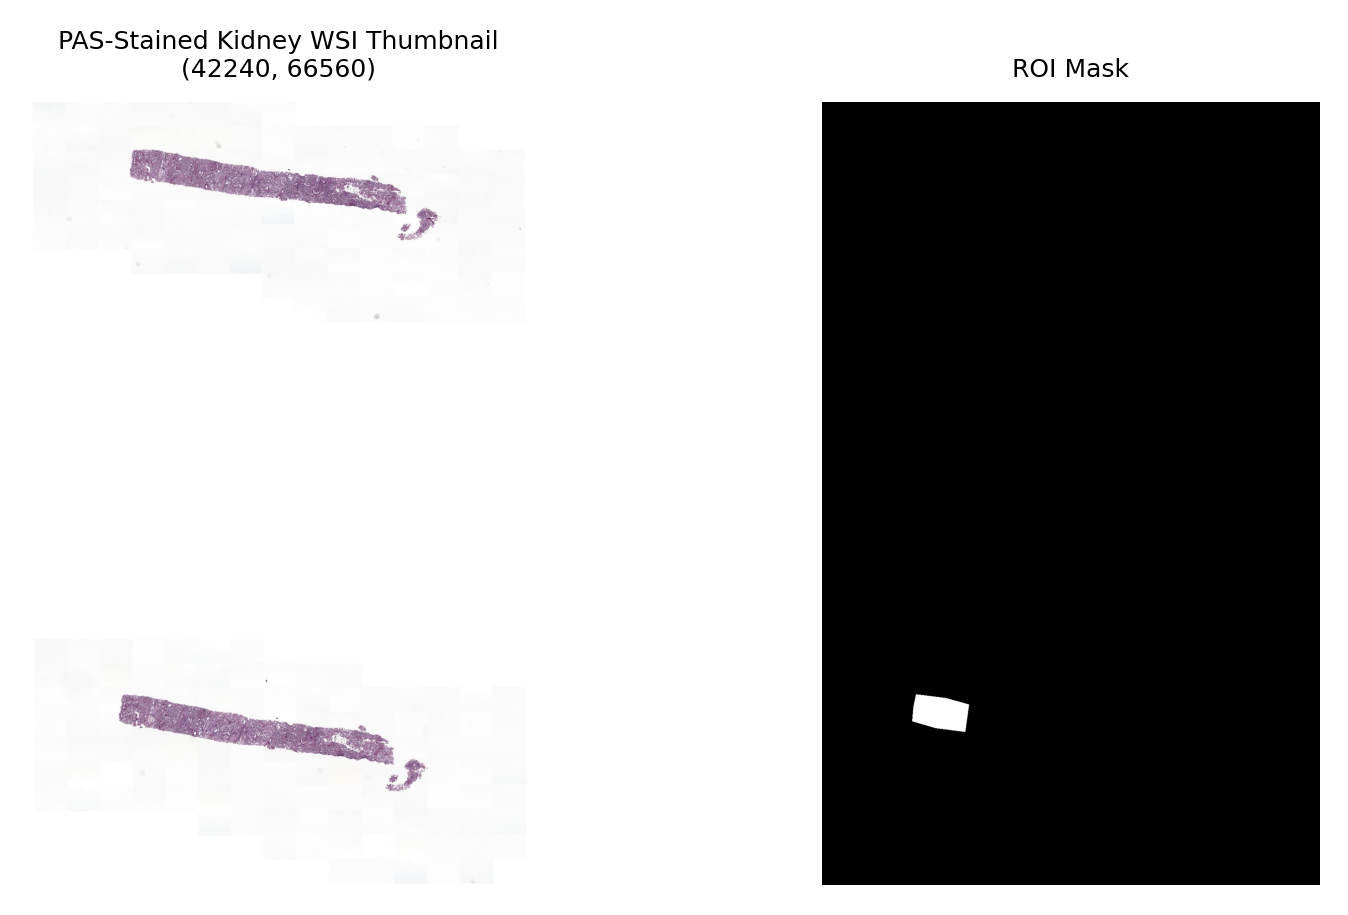

2265

In [9]:
# Open the PAS-stained kidney WSI
wsi_reader = WSIReader.open(PAS_wsi_path, mpp=0.25, power=40)
wsi_info = wsi_reader.info.as_dict()

logger.info("PAS WSI Information:")
logger.info("  Dimensions: %s", wsi_info.get("slide_dimensions"))
logger.info("  Vendor: %s", wsi_info.get("vendor"))
logger.info("  MPP: %s", wsi_info.get("mpp"))

# Display WSI thumbnail
thumbnail = wsi_reader.slide_thumbnail()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(thumbnail)
axes[0].set_title(
    f"PAS-Stained Kidney WSI Thumbnail\n{wsi_info.get('slide_dimensions', 'Unknown')}",
)
axes[0].axis("off")
axes[1].imshow(imread(PAS_wsi_mask_path), cmap="gray")
axes[1].set_title("ROI Mask")
axes[1].axis("off")
plt.tight_layout()
plt.show()

del thumbnail
gc.collect()

In the next cell, we run the detection model within the region-of-interest area indicated by the binary ROI mask shown in the previous cell. This is to reduce run time and avoid potential out-of-memory error when running on Google Colab.
If you want to run the detection model on the full image, you can set `masks=None`.



In [ ]:
# Initialize detector with model trained for immune cell detection in PAS-stained tissue
detector = NucleusDetector(
    model="KongNet_MONKEY_1",  # Trained on PAS-stained kidney biopsies
    device=device,
    verbose=True,
)

# Run detection on the PAS WSI
logger.info("Starting immune cell detection on PAS-stained WSI...")
wsi_output = detector.run(
    images=[Path(PAS_wsi_path)],
    masks=[Path(PAS_wsi_mask_path)],  # Set to None if you want to process the whole WSI
    patch_mode=False,
    device=device,
    save_dir=tmp_dir / "wsi_results/",
    overwrite=True,
    output_type="annotationstore",
    auto_get_mask=True,
    memory_threshold=50,
    num_workers=4,  # Use multiple workers for faster processing
    batch_size=8,  # Larger batch size for efficiency
)

logger.info("PAS WSI detection complete.")

### Visualization using TIAViz

In the previous cell, we ran KongNet on the entire WSI and saved the detection results as an [**AnnotationStore**](https://tia-toolbox.readthedocs.io/en/latest/_autosummary/tiatoolbox.annotation.storage.SQLiteStore.html) (specifically, a SQLite-based storage format). This AnnotationStore contains all detected nuclei with their coordinates, classifications, and other properties.

The AnnotationStore format is particularly powerful because:

- **Efficient storage**: Stores millions of detections compactly
- **Direct visualization**: Can be used directly with TIAViz for interactive exploration
- **Easy querying**: Supports fast retrieval and filtering of annotations
- **Portable**: Single file containing all detection results

Before visualizing the results with TIAViz, let's explore the AnnotationStore to understand what information it contains and view some basic statistics about our detections.



In [11]:
# Summary statistics of all detection results
logger.info("=" * 60)
logger.info("DETECTION SUMMARY")
logger.info("=" * 60)

# WSI detection statistics
if wsi_output:
    for wsi_path, annotation_path in wsi_output.items():
        wsi_store = SQLiteStore.open(annotation_path)
        wsi_name = Path(wsi_path).name
        logger.info(
            "WSI (%s): %d detections",
            wsi_name,
            len(wsi_store),
        )

        # Count detections by type if available
        detection_types = {}
        for ann in wsi_store.values():
            det_type = ann.properties.get("type", "unknown")
            detection_types[det_type] = detection_types.get(det_type, 0) + 1

        for det_type, count in detection_types.items():
            logger.info("  - %s: %d", det_type, count)

logger.info("=" * 60)

#### What is TIAViz?

TIAToolbox provides **TIAViz**, a powerful browser-based visualization tool for viewing whole slide images and overlaying model predictions or annotations. It's built using TIAToolbox and Bokeh, providing:

- **Interactive navigation**: Pan and zoom through WSIs at multiple resolutions
- **Overlay visualization**: View detection results overlaid on the original tissue
- **Multiple slides**: Compare results across different slides
- **Annotation layers**: Toggle different types of annotations on and off

#### How to use TIAViz

The command below launches a local web server that serves the visualization interface. Once running:

1. Open your web browser to the URL displayed (typically `http://localhost:5006`)
1. Navigate through the WSI using your mouse
1. View detection results as colored overlays
1. Use the interface controls to adjust visualization settings

**Important Note**: TIAViz works best when run locally on your machine rather than in Google Colab, as it requires a local web server. If you're using Colab, you can download the results and visualize them locally, or examine individual detections using the matplotlib visualization code shown earlier.



In [ ]:
%%bash
# Launch TIAViz visualization server
# This will start a local web server (typically at http://localhost:5006)
# Navigate to the displayed URL in your web browser to view the results

tiatoolbox visualize --slides ./tmp/sample_wsis/ --overlays ./tmp/wsi_results/

**Example TIAViz Visualisation**

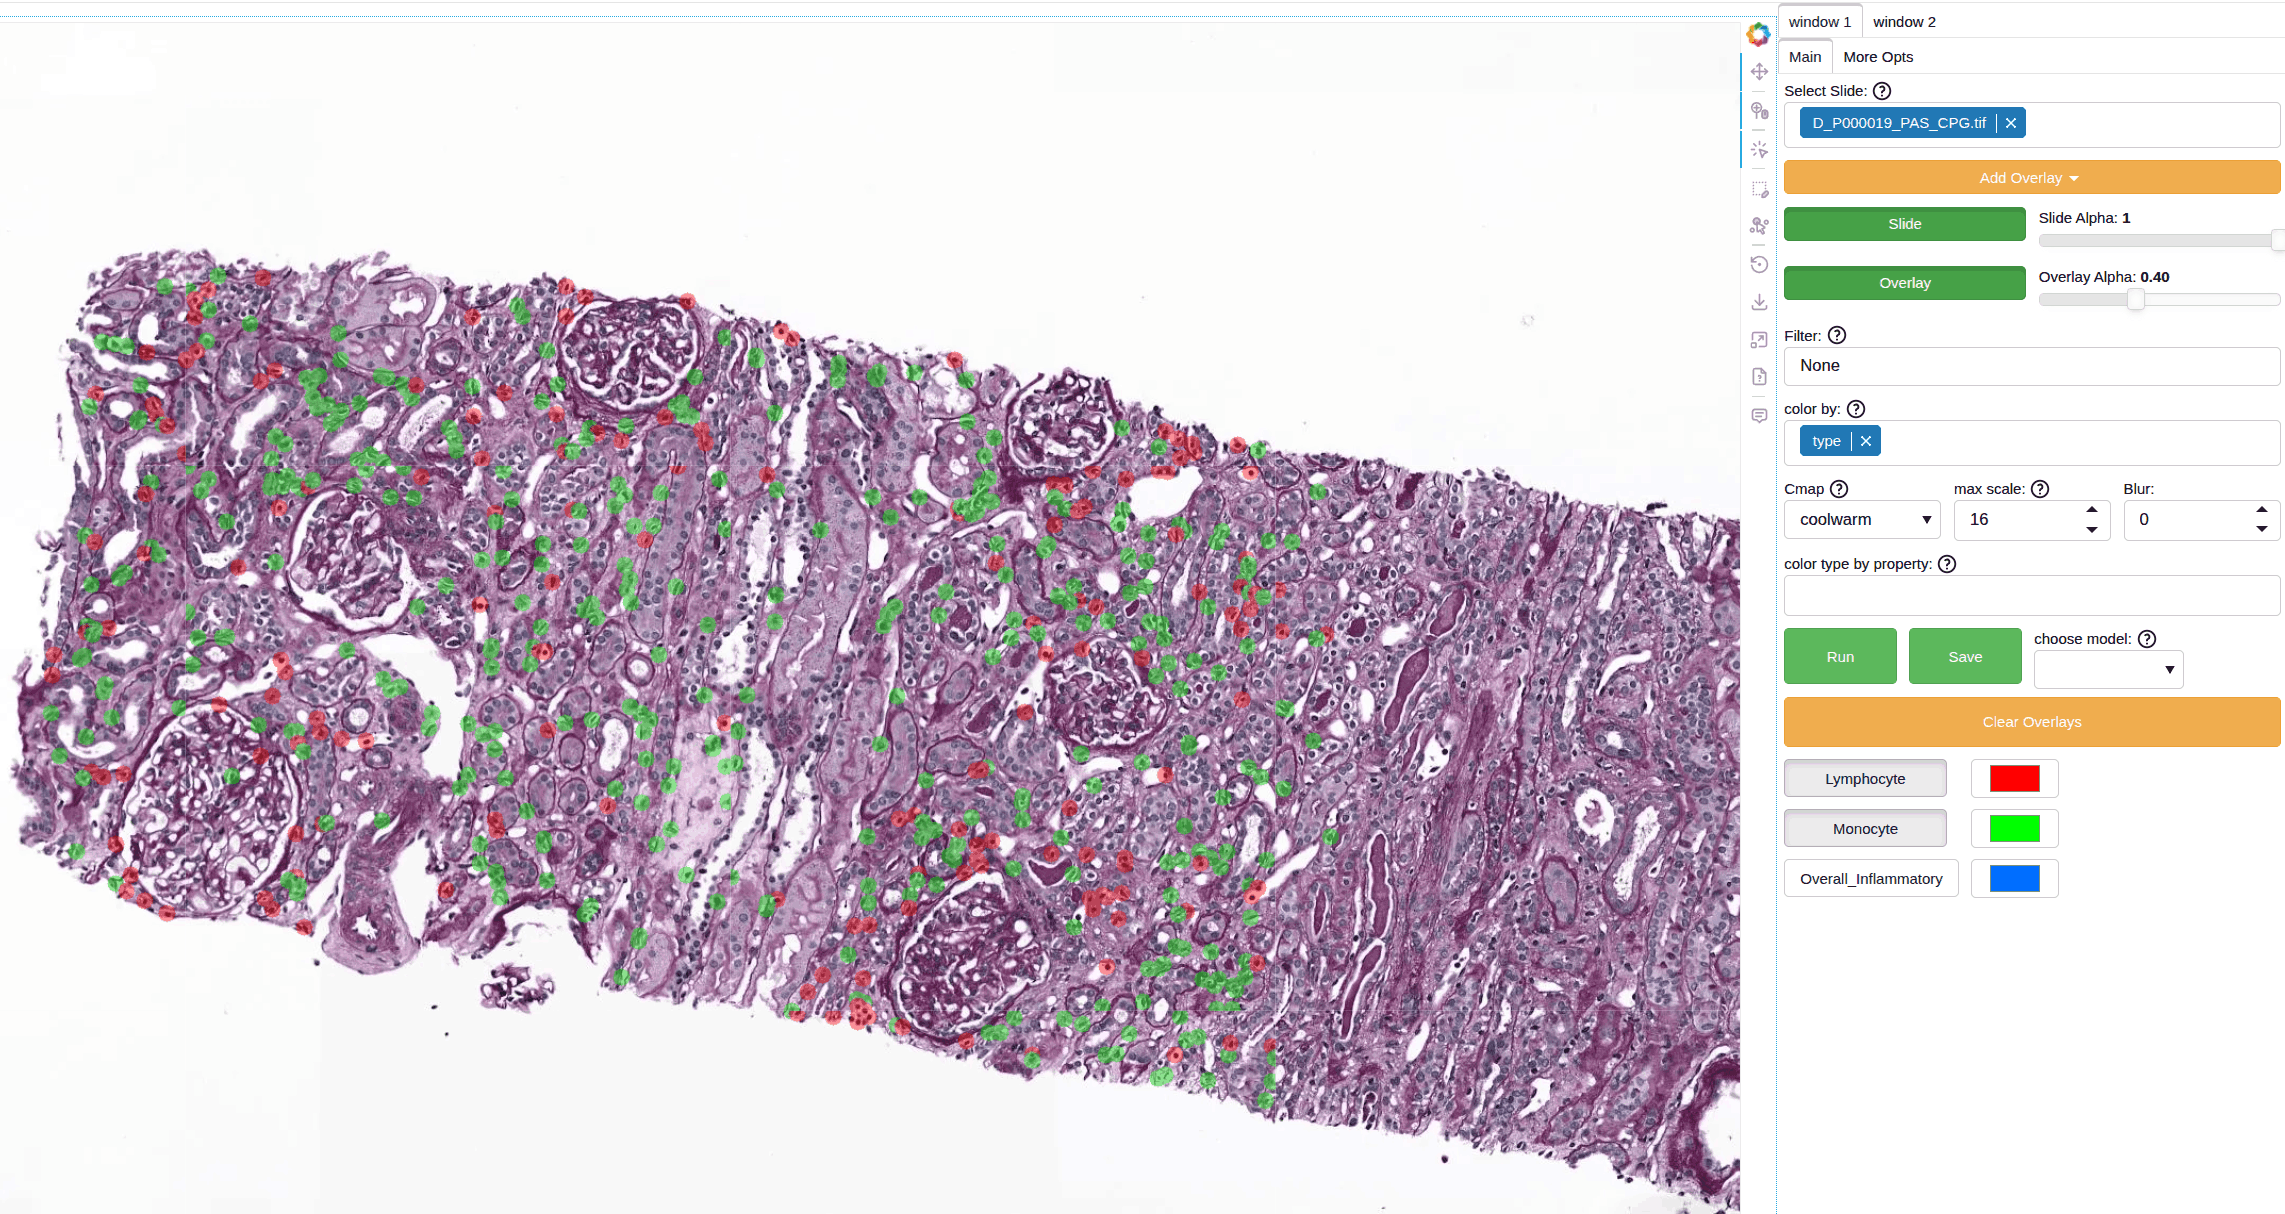



## Summary and Next Steps

### What you've learned

Congratulations! In this tutorial, you've learned how to use TIAToolbox's nucleus detection capabilities powered by KongNet. Specifically, you now know how to:

1. **Work with different modes**: Use patch mode for image patches and WSI mode for large whole slide images
1. **Use pretrained models**: Apply specialized models like `KongNet_Det_MIDOG_1` for mitosis detection and `KongNet_MONKEY_1` for immune cell detection
1. **Process different staining types**: Handle both H&E and PAS-stained tissue
1. **Interpret results**: Access and visualize detection outputs using SQLiteStore and matplotlib
1. **Visualize at scale**: Use TIAViz for interactive exploration of WSI-level results

### Key takeaways

- **Ease of use**: With just a few lines of code, you can detect and classify thousands of nuclei across entire WSIs
- **Flexibility**: The same API works for patches and WSIs, making it easy to scale your analysis
- **Multiple models**: Different pretrained models are available for different tasks and staining types
- **Efficient processing**: Automatic tissue masking and memory management make WSI processing practical

### Where to go from here

Now that you understand the basics of nucleus detection with TIAToolbox, you can:

- **Apply to your own data**: Replace the sample images with your own WSIs and patches
- **Try different models**: Explore other pretrained KongNet models like `KongNet_CoNIC_1` for the detection and classification of 6 types of nuclei
- **Customize parameters**: Adjust batch sizes, number of workers, and memory thresholds for optimal performance on your hardware
- **Integrate into pipelines**: Use the detection results for downstream analysis like spatial analysis, cell counting, or biomarker quantification
- **Explore other TIAToolbox features**: Check out other notebooks

### Additional resources

- [TIAToolbox Documentation](https://tia-toolbox.readthedocs.io/)
- [KongNet Paper](https://arxiv.org/abs/2510.23559)
- [TIAToolbox GitHub Repository](https://github.com/TissueImageAnalytics/tiatoolbox)
- [More Example Notebooks](https://github.com/TissueImageAnalytics/tiatoolbox/tree/develop/examples)

### Questions or issues?

If you encounter any problems or have questions:

- Open an issue on [GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/issues)
- Check the [documentation](https://tia-toolbox.readthedocs.io/)

Happy analyzing!

